# Day 44 — End-to-End ML Project
### Data → Preprocessing → Feature Engineering → Model → Evaluation → Pipeline

## 1. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (train_test_split, cross_val_score,
                                      GridSearchCV, StratifiedKFold)
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, roc_auc_score, roc_curve)
import joblib

plt.style.use('dark_background')
print("All imports ready! ✅")
print("Dataset: Titanic — predict survival")
print("Goal: build a production-ready ML pipeline")

All imports ready! ✅
Dataset: Titanic — predict survival
Goal: build a production-ready ML pipeline


## 2. Load & Explore Data

       LOAD & EXPLORE DATA
Shape:   (891, 12)
Columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Missing values:
Age         177
Cabin       687
Embarked      2
dtype: int64

Target distribution:
Survived
0    549
1    342
Name: count, dtype: int64

Survival rate: 38.4%


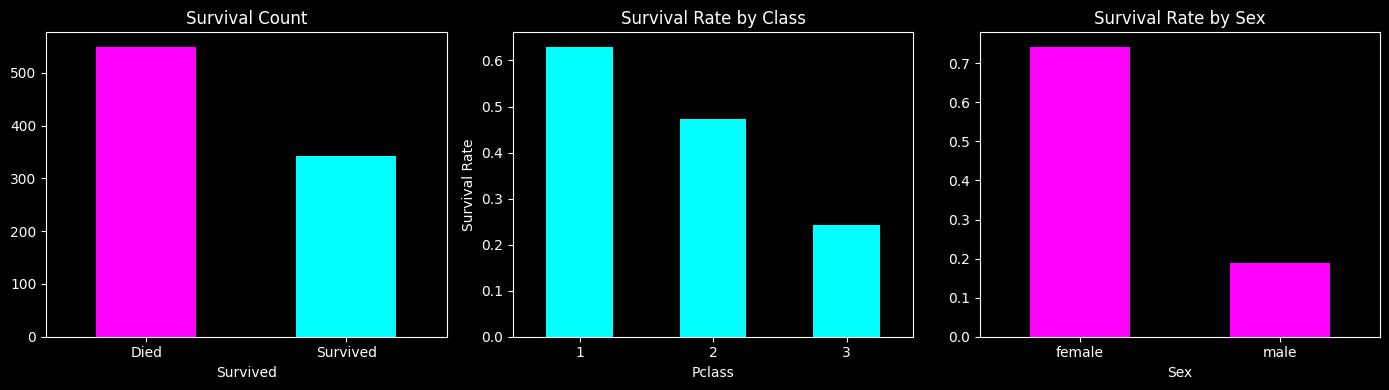

In [2]:
print("=" * 55)
print("       LOAD & EXPLORE DATA")
print("=" * 55)

df = pd.read_csv(r'C:\DS-AI-75d\titanic.csv')

print(f"Shape:   {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"\nMissing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print(f"\nTarget distribution:")
print(df['Survived'].value_counts())
print(f"\nSurvival rate: {df['Survived'].mean():.1%}")

# visualise
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# survival count
df['Survived'].value_counts().plot(kind='bar', ax=axes[0],
    color=['magenta','cyan'], rot=0)
axes[0].set_title('Survival Count')
axes[0].set_xticklabels(['Died','Survived'])

# survival by class
df.groupby('Pclass')['Survived'].mean().plot(kind='bar',
    ax=axes[1], color='cyan', rot=0)
axes[1].set_title('Survival Rate by Class')
axes[1].set_ylabel('Survival Rate')

# survival by sex
df.groupby('Sex')['Survived'].mean().plot(kind='bar',
    ax=axes[2], color='magenta', rot=0)
axes[2].set_title('Survival Rate by Sex')

plt.tight_layout()
plt.show()

## 3. Feature Engineering

In [7]:
print("=" * 55)
print("       FEATURE ENGINEERING")
print("=" * 55)

def engineer_features(df):
    df = df.copy()

    # title extraction
    df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
    title_map = {'Mr':'Mr','Miss':'Miss','Mrs':'Mrs','Master':'Master'}
    df['Title'] = df['Title'].map(title_map).fillna('Other')

    # family features
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df['IsAlone']    = (df['FamilySize'] == 1).astype(int)

    # fare features
    df['FareLog']    = np.log1p(df['Fare'])
    df['FareBin']    = pd.qcut(df['Fare'], 4, labels=['Low','Mid','High','VHigh'])

    # cabin feature
    df['HasCabin']   = df['Cabin'].notna().astype(int)

    # age bins
    df['Age']        = df['Age'].fillna(df['Age'].median())
    df['AgeBin']     = pd.cut(df['Age'], bins=[0,12,18,35,60,100],
                              labels=['Child','Teen','Adult','Middle','Senior'])

    # drop unused
    df = df.drop(['PassengerId','Name','Ticket','Cabin','Fare'], axis=1, errors='ignore')
    return df

df_eng = engineer_features(df)
print(f"Original features:    {df.shape[1]}")
print(f"Engineered features:  {df_eng.shape[1]}")
print(f"\nNew features added:")
new_cols = ['Title','FamilySize','IsAlone','FareLog','FareBin','HasCabin','AgeBin']
for col in new_cols:
    print(f"  {col:<15} → {df_eng[col].value_counts().to_dict()}")

       FEATURE ENGINEERING
Original features:    12
Engineered features:  14

New features added:
  Title           → {'Mr': 517, 'Miss': 182, 'Mrs': 125, 'Master': 40, 'Other': 27}
  FamilySize      → {1: 537, 2: 161, 3: 102, 4: 29, 6: 22, 5: 15, 7: 12, 11: 7, 8: 6}
  IsAlone         → {1: 537, 0: 354}
  FareLog         → {2.2027647577118348: 43, 2.6390573296152584: 42, 2.1855792552411137: 38, 2.169053700369523: 34, 3.295836866004329: 31, 2.4423470353692043: 24, 2.188856327665703: 18, 2.1719067693519296: 16, 2.1076888046179385: 15, 3.3160025355989236: 15, 0.0: 15, 2.180891922715322: 13, 2.1102132003465894: 13, 2.2682524139135403: 13, 2.1071782966514356: 12, 2.8390784635086144: 9, 2.3513752571634776: 9, 2.803360380906535: 8, 3.224857896545748: 8, 4.256321678298823: 7, 3.970291913552122: 7, 4.05171190165724: 7, 3.4742929367327062: 7, 2.737880811060884: 7, 2.0856720914304723: 7, 2.740840023925201: 7, 3.705920919968788: 6, 3.8691155044168695: 6, 3.3638415951183864: 6, 3.091042453358316: 6

## 4. Build Production ML Pipeline

In [8]:
print("=" * 55)
print("       BUILD ML PIPELINE")
print("=" * 55)

# define features
num_features = ['Age', 'SibSp', 'Parch', 'FareLog', 'FamilySize', 'IsAlone', 'HasCabin']
cat_features = ['Pclass', 'Sex', 'Embarked', 'Title', 'FareBin', 'AgeBin']

X = df_eng.drop('Survived', axis=1)
y = df_eng['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# preprocessing pipelines
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features)
])

# full pipelines for each model
models = {
    'Logistic Regression': Pipeline([
        ('prep', preprocessor),
        ('clf',  LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('prep', preprocessor),
        ('clf',  RandomForestClassifier(n_estimators=100, random_state=42))
    ]),
    'Gradient Boosting': Pipeline([
        ('prep', preprocessor),
        ('clf',  GradientBoostingClassifier(n_estimators=100, random_state=42))
    ]),
}

print(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")
print(f"Numeric features:     {num_features}")
print(f"Categorical features: {cat_features}")
print(f"\nTraining 3 models...")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}
for name, pipeline in models.items():
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='accuracy')
    pipeline.fit(X_train, y_train)
    test_acc = accuracy_score(y_test, pipeline.predict(X_test))
    results[name] = {'cv_mean': cv_scores.mean(), 'cv_std': cv_scores.std(), 'test_acc': test_acc}
    print(f"  {name:<25} CV: {cv_scores.mean():.4f} ± {cv_scores.std():.4f} | Test: {test_acc:.4f}")

print("\nDone! ✅")

       BUILD ML PIPELINE
Train size: 712 | Test size: 179
Numeric features:     ['Age', 'SibSp', 'Parch', 'FareLog', 'FamilySize', 'IsAlone', 'HasCabin']
Categorical features: ['Pclass', 'Sex', 'Embarked', 'Title', 'FareBin', 'AgeBin']

Training 3 models...
  Logistic Regression       CV: 0.8174 ± 0.0290 | Test: 0.8380
  Random Forest             CV: 0.8189 ± 0.0175 | Test: 0.7877
  Gradient Boosting         CV: 0.8259 ± 0.0248 | Test: 0.8156

Done! ✅


## 5. Evaluate Best Model

       EVALUATE BEST MODEL
Model:    Logistic Regression
Accuracy: 0.8380
ROC-AUC:  0.8663

Classification Report:
              precision    recall  f1-score   support

        Died       0.86      0.87      0.87       110
    Survived       0.79      0.78      0.79        69

    accuracy                           0.84       179
   macro avg       0.83      0.83      0.83       179
weighted avg       0.84      0.84      0.84       179



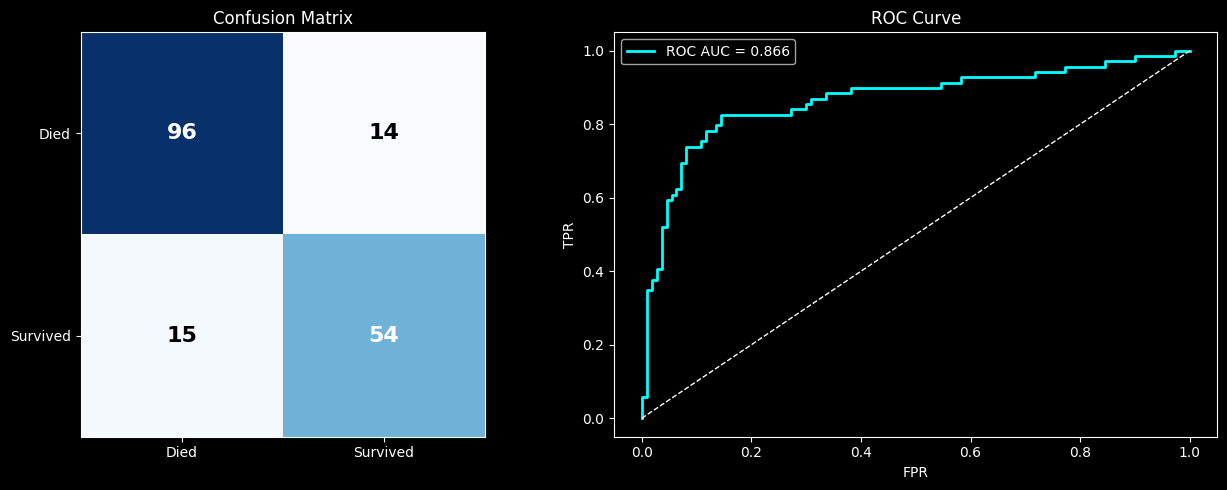

In [9]:
print("=" * 55)
print("       EVALUATE BEST MODEL")
print("=" * 55)

# best model = Logistic Regression
best_model = models['Logistic Regression']
y_pred     = best_model.predict(X_test)
y_prob     = best_model.predict_proba(X_test)[:, 1]

print(f"Model:    Logistic Regression")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:  {roc_auc_score(y_test, y_prob):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Died','Survived']))

# plots
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
im = axes[0].imshow(cm, cmap='Blues')
axes[0].set_xticks([0,1]); axes[0].set_yticks([0,1])
axes[0].set_xticklabels(['Died','Survived'])
axes[0].set_yticklabels(['Died','Survived'])
axes[0].set_title('Confusion Matrix')
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm[i,j], ha='center', va='center',
                     fontsize=16, fontweight='bold',
                     color='white' if cm[i,j] > cm.max()/2 else 'black')

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
axes[1].plot(fpr, tpr, color='cyan', linewidth=2, label=f'ROC AUC = {auc:.3f}')
axes[1].plot([0,1],[0,1], color='white', linestyle='--', linewidth=1)
axes[1].set_title('ROC Curve'); axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Save & Load Pipeline

In [10]:
print("=" * 55)
print("       SAVE & LOAD PIPELINE")
print("=" * 55)

# save pipeline
model_path = r'C:\DS-AI-75d\titanic_pipeline.pkl'
joblib.dump(best_model, model_path)
print(f"Model saved to: {model_path} ✅")

# load pipeline
loaded_model = joblib.load(model_path)
print(f"Model loaded! ✅")

# verify predictions match
y_pred_loaded = loaded_model.predict(X_test)
print(f"Predictions match: {(y_pred == y_pred_loaded).all()} ✅")

# predict on new passengers
print(f"\nPREDICT ON NEW PASSENGERS:")
new_passengers = pd.DataFrame({
    'Pclass':     [1, 3],
    'Sex':        ['female', 'male'],
    'Age':        [29, 22],
    'SibSp':      [0, 1],
    'Parch':      [0, 0],
    'Ticket':     ['PC 1', 'S/O 1'],
    'Fare':       [100, 7.25],
    'Cabin':      ['C85', None],
    'Embarked':   ['S', 'S'],
    'Name':       ['Smith, Mrs. A', 'Jones, Mr. B'],
})
new_eng  = engineer_features(new_passengers)
new_pred = loaded_model.predict(new_eng)
new_prob = loaded_model.predict_proba(new_eng)[:, 1]

for i, (pred, prob) in enumerate(zip(new_pred, new_prob)):
    label = "SURVIVED ✅" if pred == 1 else "DIED ❌"
    print(f"  Passenger {i+1}: {label} (prob={prob:.2f})")
    print(f"    Class={new_passengers['Pclass'].iloc[i]}, "
          f"Sex={new_passengers['Sex'].iloc[i]}, "
          f"Age={new_passengers['Age'].iloc[i]}")

       SAVE & LOAD PIPELINE
Model saved to: C:\DS-AI-75d\titanic_pipeline.pkl ✅
Model loaded! ✅
Predictions match: True ✅

PREDICT ON NEW PASSENGERS:
  Passenger 1: SURVIVED ✅ (prob=0.98)
    Class=1, Sex=female, Age=29
  Passenger 2: DIED ❌ (prob=0.06)
    Class=3, Sex=male, Age=22


## 7. Key Takeaways

In [11]:
print("=" * 55)
print("       DAY 44 — KEY TAKEAWAYS")
print("=" * 55)
print("""
END-TO-END ML PIPELINE:
  ✅ Load & Explore  → understand data, spot issues
  ✅ Feature Engineer → create meaningful new features
  ✅ Preprocessing   → impute, scale, encode
  ✅ Train & Compare → cross-validate multiple models
  ✅ Evaluate        → accuracy, AUC, confusion matrix
  ✅ Save & Deploy   → joblib save/load for production

FEATURE ENGINEERING:
  ✅ Title from Name      → Mr, Mrs, Miss, Master
  ✅ FamilySize + IsAlone → social context
  ✅ FareLog             → handle skewed distributions
  ✅ HasCabin            → binary from missing data
  ✅ AgeBin              → discretise continuous feature

SKLEARN PIPELINE:
  ✅ ColumnTransformer   → different transforms per column
  ✅ Pipeline            → chain preprocessing + model
  ✅ No data leakage     → fit only on train, transform both
  ✅ One object to save  → preprocessing + model together

MODEL COMPARISON:
  ✅ Logistic Regression → 83.8% test, simple & interpretable
  ✅ Gradient Boosting   → 82.6% CV, best generaliser
  ✅ Random Forest       → slight overfit on this dataset
  ✅ Always use CV       → more reliable than single split

PRODUCTION READY:
  ✅ joblib.dump()  → save entire pipeline
  ✅ joblib.load()  → load and predict instantly
  ✅ New data goes through same preprocessing automatically
""")

       DAY 44 — KEY TAKEAWAYS

END-TO-END ML PIPELINE:
  ✅ Load & Explore  → understand data, spot issues
  ✅ Feature Engineer → create meaningful new features
  ✅ Preprocessing   → impute, scale, encode
  ✅ Train & Compare → cross-validate multiple models
  ✅ Evaluate        → accuracy, AUC, confusion matrix
  ✅ Save & Deploy   → joblib save/load for production

FEATURE ENGINEERING:
  ✅ Title from Name      → Mr, Mrs, Miss, Master
  ✅ FamilySize + IsAlone → social context
  ✅ FareLog             → handle skewed distributions
  ✅ HasCabin            → binary from missing data
  ✅ AgeBin              → discretise continuous feature

SKLEARN PIPELINE:
  ✅ ColumnTransformer   → different transforms per column
  ✅ Pipeline            → chain preprocessing + model
  ✅ No data leakage     → fit only on train, transform both
  ✅ One object to save  → preprocessing + model together

MODEL COMPARISON:
  ✅ Logistic Regression → 83.8% test, simple & interpretable
  ✅ Gradient Boosting   → 82.6% C